In [19]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [20]:
train_size = 379


In [21]:
def topk_per_d_per_method(data, param_cols, k=3):
    """
    Return up to the top-k configs per (d, method), ranked by avg_rmse.
    `data` can be a CSV path or a pandas DataFrame.
    `param_cols` MUST include 'd' and 'method' plus any hyperparams.
    """
    # Load
    df = pd.read_csv(data) if isinstance(data, str) else data.copy()

    # Safety checks
    required = set(param_cols) | {'seed', 'rmse', 'mae'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in data: {sorted(missing)}")

    # Aggregate across seeds for each unique config
    agg = (df.groupby(param_cols, as_index=False)
             .agg(avg_rmse=('rmse','mean'),
                  avg_mae=('mae','mean'),
                  n_seeds=('seed','nunique')))

    # Rank within (d, method) and take top-k (handles <k gracefully)
    out = (agg.sort_values(['method','avg_rmse'])
              .groupby(['method'], group_keys=False)
              .apply(lambda g: g.nsmallest(k, 'avg_rmse'))
              .reset_index(drop=True))

    return out


In [22]:
top3_xgb_all = topk_per_d_per_method(
    f'results/ablation_transfer_real_xgboost_{train_size}.csv',
    param_cols=['method', 'v', 'target_tree_size'],
    k=3
)

# If you want separate DataFrames:
top3_xgb_plain  = top3_xgb_all[top3_xgb_all['method'] == 'xgboost'].reset_index(drop=True)
top3_xgb_naive  = top3_xgb_all[top3_xgb_all['method'] == 'xgboost_naive_transfer'].reset_index(drop=True)

print("Top 3 per d — plain XGBoost:\n")
top3_xgb_plain

Top 3 per d — plain XGBoost:



C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_28560\1918412423.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nsmallest(k, 'avg_rmse'))


,method,v,target_tree_size,avg_rmse,avg_mae,n_seeds
0,xgboost,0.02,1,7.201818,4.909273,1
1,xgboost,0.05,1,7.202425,4.910416,1
2,xgboost,0.10,1,7.208982,4.919525,1


In [23]:
print("\nTop 3 per d — XGBoost Naive Transfer:\n")
top3_xgb_naive


Top 3 per d — XGBoost Naive Transfer:



,method,v,target_tree_size,avg_rmse,avg_mae,n_seeds
0,xgboost_naive_transfer,0.01,4,7.516775,5.544899,1
1,xgboost_naive_transfer,0.02,4,7.521957,5.558714,1
2,xgboost_naive_transfer,0.05,4,7.527026,5.571837,1


In [24]:
top3_mlp = topk_per_d_per_method(
    f'results/ablation_transfer_real_MLP_{train_size}.csv',
    param_cols=['method', 'base_lr', 'fine_tuning_lr', 'dropout_rate', 'batch_norm'],
    k=1
)
print("Top 3 per d — MLP finetuning:\n")
top3_mlp

Top 3 per d — MLP finetuning:



C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_28560\1918412423.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nsmallest(k, 'avg_rmse'))


,method,base_lr,fine_tuning_lr,dropout_rate,batch_norm,avg_rmse,avg_mae,n_seeds
0,MLP,0.0005,0.00005,0.0,True,7.162867,4.760743,1


In [25]:
top3_transfer = topk_per_d_per_method(
    f'results/ablation_transfer_real_{train_size}.csv',
    param_cols=['method', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'],
    k=3
)
print("Top 3 per d — TransferTreeBoost:\n")
top3_transfer

Top 3 per d — TransferTreeBoost:



C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_28560\1918412423.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nsmallest(k, 'avg_rmse'))


,method,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,avg_mae,n_seeds
0,LSTransferTreeBoost,0.05,1,1,0.01,0.5,7.111722,4.823326,1


In [26]:
df = pd.concat((top3_xgb_plain[['method', 'avg_rmse', 'avg_mae']], top3_xgb_naive[['method', 'avg_rmse', 'avg_mae']]))
df = pd.concat((df, top3_mlp[['method', 'avg_rmse', 'avg_mae']]))
df = pd.concat((df, top3_transfer[['method', 'avg_rmse', 'avg_mae']]))

<Axes: xlabel='method', ylabel='avg_rmse'>

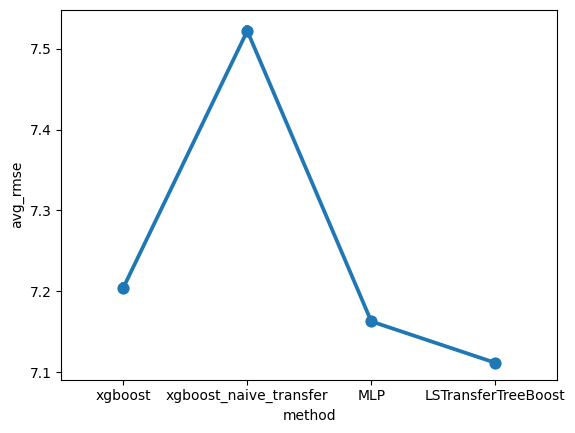

In [27]:
sns.pointplot(data=df, x='method', y='avg_rmse')